In [1]:
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

- [ ] Do anomalous laps cluster around a specific cause (Safety Car vs. genuine mistake) more for some drivers/teams than others? (categorize causes, chi-square)
- [ ] Is a driver's sector strength consistent across multiple races (a real skill signal), or does it vary too much to be meaningful? (variance/consistency check across sessions)

- [ ] When teammates' strategies diverge, what predicts which one pays off pit timing, track position at the stop, or pure pace? (logistic regression: better-finisher ~ predictors)
- [ ] Is there a statistically real advantage to a specific strategy (fewer stops, a particular compound order) at a given circuit, or does it wash out once you control for starting position? (t-test / ANOVA comparing outcomes by strategy group)

- [X] Do anomalous laps cluster around a specific cause (Safety Car vs. genuine mistake) more for some drivers/teams than others? (categorize causes, chi-square)

In [2]:
import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

query = """
WITH lap_causes AS (
    SELECT session_key, lap_number,
           MAX(CASE WHEN category = 'SafetyCar' THEN 1 ELSE 0 END) AS has_sc,
           MAX(CASE WHEN category = 'Flag' AND flag = 'RED' THEN 1 ELSE 0 END) AS has_red,
           MAX(CASE WHEN category = 'Flag' AND flag IN ('YELLOW','DOUBLE YELLOW') THEN 1 ELSE 0 END) AS has_yellow
    FROM silver_race_control
    WHERE lap_number IS NOT NULL
    GROUP BY session_key, lap_number
)
SELECT l.*, s.year, s.session_name, m.meeting_name, d.team_name, d.full_name,
       COALESCE(c.has_sc, 0) AS has_sc,
       COALESCE(c.has_red, 0) AS has_red,
       COALESCE(c.has_yellow, 0) AS has_yellow
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key
JOIN silver_meetings m ON s.meeting_key = m.meeting_key
JOIN silver_drivers d ON l.session_key = d.session_key AND l.driver_number = d.driver_number
LEFT JOIN lap_causes c ON l.session_key = c.session_key AND l.lap_number = c.lap_number
WHERE s.session_name = 'Race'
  AND l.lap_duration IS NOT NULL
  AND l.is_pit_out_lap = 0
  AND l.lap_duration BETWEEN 60 AND 200
"""

df_laps = pd.read_sql(query, conn)
df_laps.shape
df_laps[['has_sc','has_red','has_yellow']].sum()

has_sc        2192
has_red         49
has_yellow    3900
dtype: int64

In [3]:
stints_query = """
SELECT session_key, driver_number, stint_number,
       compound, tyre_age_at_start, lap_start, lap_end
FROM silver_stints
WHERE lap_end >= lap_start
"""
df_stints = pd.read_sql(stints_query, conn)

df_merged = df_laps.merge(df_stints, on=['session_key','driver_number'], how='left')
df_merged = df_merged[
    (df_merged['lap_number'] >= df_merged['lap_start']) &
    (df_merged['lap_number'] <= df_merged['lap_end'])
]

stint_median = df_merged.groupby(['session_key','driver_number','stint_number'])['lap_duration'].transform('median')
df_merged['pct_over_stint_median'] = (df_merged['lap_duration'] - stint_median) / stint_median

slow_anomalies = df_merged[df_merged['pct_over_stint_median'] > 0.20].copy()
slow_anomalies.shape
slow_anomalies[['has_sc','has_red','has_yellow']].sum()

has_sc        1276
has_red         35
has_yellow     966
dtype: int64

In [4]:
slow_anomalies.shape
(slow_anomalies['has_sc'] | slow_anomalies['has_red'] | slow_anomalies['has_yellow']).sum()

np.int64(1697)

In [5]:
def categorize(row):
    if row['has_sc']:
        return 'SafetyCar'
    elif row['has_red']:
        return 'RedFlag'
    elif row['has_yellow']:
        return 'YellowFlag'
    else:
        return 'Uncaught'

slow_anomalies['cause'] = slow_anomalies.apply(categorize, axis=1)
slow_anomalies['cause'].value_counts()

cause
Uncaught      1358
SafetyCar     1276
YellowFlag     389
RedFlag         32
Name: count, dtype: int64

In [6]:
from data_prep import normalize_team_names
slow_anomalies = normalize_team_names(slow_anomalies)

In [10]:
# Option A: drop RedFlag
table_no_red = table_team.drop(columns='RedFlag')
chi2, p, dof, expected = chi2_contingency(table_no_red)
print(f"chi2={chi2:.3f}, p={p:.6f}, dof={dof}, expected<5 cells: {(expected<5).sum()}")


chi2=20.051, p=0.454756, dof=20, expected<5 cells: 0


In [12]:
from scipy.stats import chi2_contingency

table_team = pd.crosstab(slow_anomalies['team_name'], slow_anomalies['cause'])
print(table_team)

chi2, p, dof, expected = chi2_contingency(table_team)
print(f"\nchi2={chi2:.3f}, p={p:.6f}, dof={dof}")

# check for expected cells below 5, which would make chi-square unreliable
low_cells = (expected < 5).sum()
print(f"Expected cells < 5: {low_cells} (chi-square unreliable if this is large)")

cause            RedFlag  SafetyCar  Uncaught  YellowFlag
team_name                                                
Alpine                 4        121       148          40
Aston Martin           3        120       127          37
Cadillac               0         11        25           8
Ferrari                4        144       132          34
Haas F1 Team           2        112       135          49
McLaren                3        144       143          42
Mercedes               6        139       120          31
RB Family              4        118       129          33
Red Bull Racing        3        133       137          36
Sauber Family          2        116       132          37
Williams               1        118       130          42

chi2=26.182, p=0.665785, dof=30
Expected cells < 5: 11 (chi-square unreliable if this is large)


In [9]:
table_clean = table_team.drop(columns='RedFlag').drop(index='Cadillac')
chi2, p, dof, expected = chi2_contingency(table_clean)
print(table_clean)
print(f"\nchi2={chi2:.3f}, p={p:.6f}, dof={dof}, expected<5 cells: {(expected<5).sum()}")

cause            SafetyCar  Uncaught  YellowFlag
team_name                                       
Alpine                 121       148          40
Aston Martin           120       127          37
Ferrari                144       132          34
Haas F1 Team           112       135          49
McLaren                144       143          42
Mercedes               139       120          31
RB Family              118       129          33
Red Bull Racing        133       137          36
Sauber Family          116       132          37
Williams               118       130          42

chi2=14.541, p=0.693192, dof=18, expected<5 cells: 0




DATA CLEANING FOR RELIABILITY:
- Dropped RedFlag category (only 32 total anomalies, produced 11+ expected cells 
  below 5, unreliable for chi-square).
- Dropped Cadillac team (brand-new 2026 team, partial season, only ~44 total 
  anomalies vs 300+ per established team -- consistent with the exclusion 
  applied in the tyre degradation question).

RESULT: chi2=14.54, p=0.693, dof=18 -- NOT SIGNIFICANT.
Every team's distribution across causes was nearly identical (~30% SC, ~35% 
Uncaught, ~10% Yellow proportionally). No team is disproportionately represented 
in any specific cause category.

INTERPRETATION: When a driver has an anomalously slow lap, the cause distribution 
(Safety Car vs Yellow Flag vs Uncaught/genuine mistake or unlogged event) doesn't 
depend on which team they drive for. This is a real, meaningful null result -- 
sample sizes were adequate across all cells to detect a real effect if one existed.

IMPORTANT LIMITATION -- "UNCAUGHT" IS A MIXED BAG: The largest single category 
(~44% of anomalies) has no race-control tag at that exact lap_number. Consistent 
with the previously-documented finding (Albon 2023 Azerbaijan Sprint) that race 
control's lap_number tagging isn't exhaustive -- multi-lap events like SC 
deployments often don't tag every affected lap, and yellow flags on specific track 
sectors may not tag the lap_number field either. So "Uncaught" mixes 
GENUINE driver mistakes with LOGGING GAPS from race-control-attributable events. 
This limits the extent to which this analysis can cleanly distinguish "SafetyCar" 
vs "genuine mistake" as the ORIGINAL question phrased -- the honest scope is 
"race-control-tagged vs not-tagged," not a pure cause attribution.

TAKEAWAY: no team-level clustering of anomaly causes, and no team is unusually 
prone to any specific type of slow-lap event. Combined with the earlier finding 
that tyre degradation rate also doesn't differ by team, a broader pattern is 
emerging: at the team level, lap-time performance and anomaly patterns look 
statistically indistinguishable once compound and stint context are held constant. 
Real differences likely live at the DRIVER level (as confirmed in the earlier 
teammate-quali-delta analysis) rather than the team level.

- [X] Is a driver's sector strength consistent across multiple races (a real skill signal), or does it vary too much to be meaningful? (variance/consistency check across sessions)

In [31]:
sectors_query = """
SELECT gs.year, gm.meeting_name, l.session_key, l.driver_number,
       d.team_name, d.full_name,
       l.duration_sector_1, l.duration_sector_2, l.duration_sector_3
FROM silver_laps l
JOIN silver_sessions gs ON l.session_key = gs.session_key AND gs.session_name = 'Race'
JOIN silver_meetings gm ON gs.meeting_key = gm.meeting_key
JOIN silver_drivers d ON l.session_key = d.session_key AND l.driver_number = d.driver_number
WHERE l.duration_sector_1 IS NOT NULL 
  AND l.duration_sector_2 IS NOT NULL 
  AND l.duration_sector_3 IS NOT NULL
"""
df_sectors = pd.read_sql(sectors_query, conn)
df_sectors = normalize_team_names(df_sectors)
df_sectors.shape

(80808, 9)

In [32]:
sector_medians = df_sectors.groupby(
    ['session_key','year','meeting_name','team_name','driver_number','full_name']
).agg(
    s1=('duration_sector_1','median'),
    s2=('duration_sector_2','median'),
    s3=('duration_sector_3','median'),
    n_laps=('duration_sector_1','count')
).reset_index()

sector_medians = sector_medians[sector_medians['n_laps'] >= 25].copy()
sector_medians.shape

(1369, 10)

In [33]:
pair_data = sector_medians.merge(
    sector_medians,
    on=['session_key','year','meeting_name','team_name'],
    suffixes=('_a','_b')
)
pair_data = pair_data[pair_data['driver_number_a'] < pair_data['driver_number_b']].copy()

pair_data['delta_s1'] = pair_data['s1_a'] - pair_data['s1_b']
pair_data['delta_s2'] = pair_data['s2_a'] - pair_data['s2_b']
pair_data['delta_s3'] = pair_data['s3_a'] - pair_data['s3_b']

pair_data['pair_id'] = (
    pair_data['team_name'] + '_' + 
    pair_data['driver_number_a'].astype(str) + '_' + 
    pair_data['driver_number_b'].astype(str)
)

pair_data.shape

(637, 20)

In [34]:
from scipy import stats

# same >=8 shared races threshold as teammate quali analysis
pair_counts = pair_data.groupby('pair_id').size()
valid_pairs = pair_counts[pair_counts >= 8].index
pair_data_clean = pair_data[pair_data['pair_id'].isin(valid_pairs)].copy()

results = []
for pair_id, group in pair_data_clean.groupby('pair_id'):
    for sector_col, sector_label in [('delta_s1','sector_1'),('delta_s2','sector_2'),('delta_s3','sector_3')]:
        t_stat, p_value = stats.ttest_1samp(group[sector_col], popmean=0)
        results.append({
            'pair_id': pair_id,
            'sector': sector_label,
            'n_races': len(group),
            'mean_delta': group[sector_col].mean(),
            'std_delta': group[sector_col].std(),
            't_stat': t_stat,
            'p_value': p_value
        })

pair_sector_tests = pd.DataFrame(results)

n_tests = len(pair_sector_tests)
alpha_corrected = 0.05 / n_tests
pair_sector_tests['significant'] = pair_sector_tests['p_value'] < alpha_corrected

print(f"n_tests: {n_tests}, alpha_corrected: {alpha_corrected:.5f}")
print(f"Significant (real consistent signal): {pair_sector_tests['significant'].sum()} of {n_tests}")

pair_sector_tests.sort_values('p_value')

n_tests: 57, alpha_corrected: 0.00088
Significant (real consistent signal): 9 of 57


,pair_id,sector,n_races,mean_delta,std_delta,t_stat,p_value,significant
40,Red Bull Racing_1_11,sector_2,38,-0.250987,0.328069,-4.716045,0.000034,True
43,Red Bull Racing_1_22,sector_2,18,-0.515250,0.395642,-5.525255,0.000037,True
23,McLaren_4_81,sector_3,60,-0.090217,0.158793,-4.400805,0.000046,True
42,Red Bull Racing_1_22,sector_1,18,-0.298056,0.236746,-5.341337,0.000054,True
41,Red Bull Racing_1_11,sector_3,38,-0.156737,0.214391,-4.506672,0.000064,True
17,Haas F1 Team_20_27,sector_3,38,0.135566,0.186612,4.478194,0.000070,True
44,Red Bull Racing_1_22,sector_3,18,-0.365750,0.333207,-4.656996,0.000226,True
1,Alpine_10_31,sector_2,35,-0.126371,0.197420,-3.786966,0.000594,True
55,Williams_2_23,sector_2,28,0.117304,0.161472,3.844076,0.000668,True
54,Williams_2_23,sector_1,28,0.082446,0.127041,3.434041,0.001935,False


In [35]:
pair_sector_tests[pair_sector_tests['significant']].sort_values('p_value')

,pair_id,sector,n_races,mean_delta,std_delta,t_stat,p_value,significant
40,Red Bull Racing_1_11,sector_2,38,-0.250987,0.328069,-4.716045,0.000034,True
43,Red Bull Racing_1_22,sector_2,18,-0.515250,0.395642,-5.525255,0.000037,True
23,McLaren_4_81,sector_3,60,-0.090217,0.158793,-4.400805,0.000046,True
42,Red Bull Racing_1_22,sector_1,18,-0.298056,0.236746,-5.341337,0.000054,True
41,Red Bull Racing_1_11,sector_3,38,-0.156737,0.214391,-4.506672,0.000064,True
17,Haas F1 Team_20_27,sector_3,38,0.135566,0.186612,4.478194,0.000070,True
44,Red Bull Racing_1_22,sector_3,18,-0.365750,0.333207,-4.656996,0.000226,True
1,Alpine_10_31,sector_2,35,-0.126371,0.197420,-3.786966,0.000594,True
55,Williams_2_23,sector_2,28,0.117304,0.161472,3.844076,0.000668,True


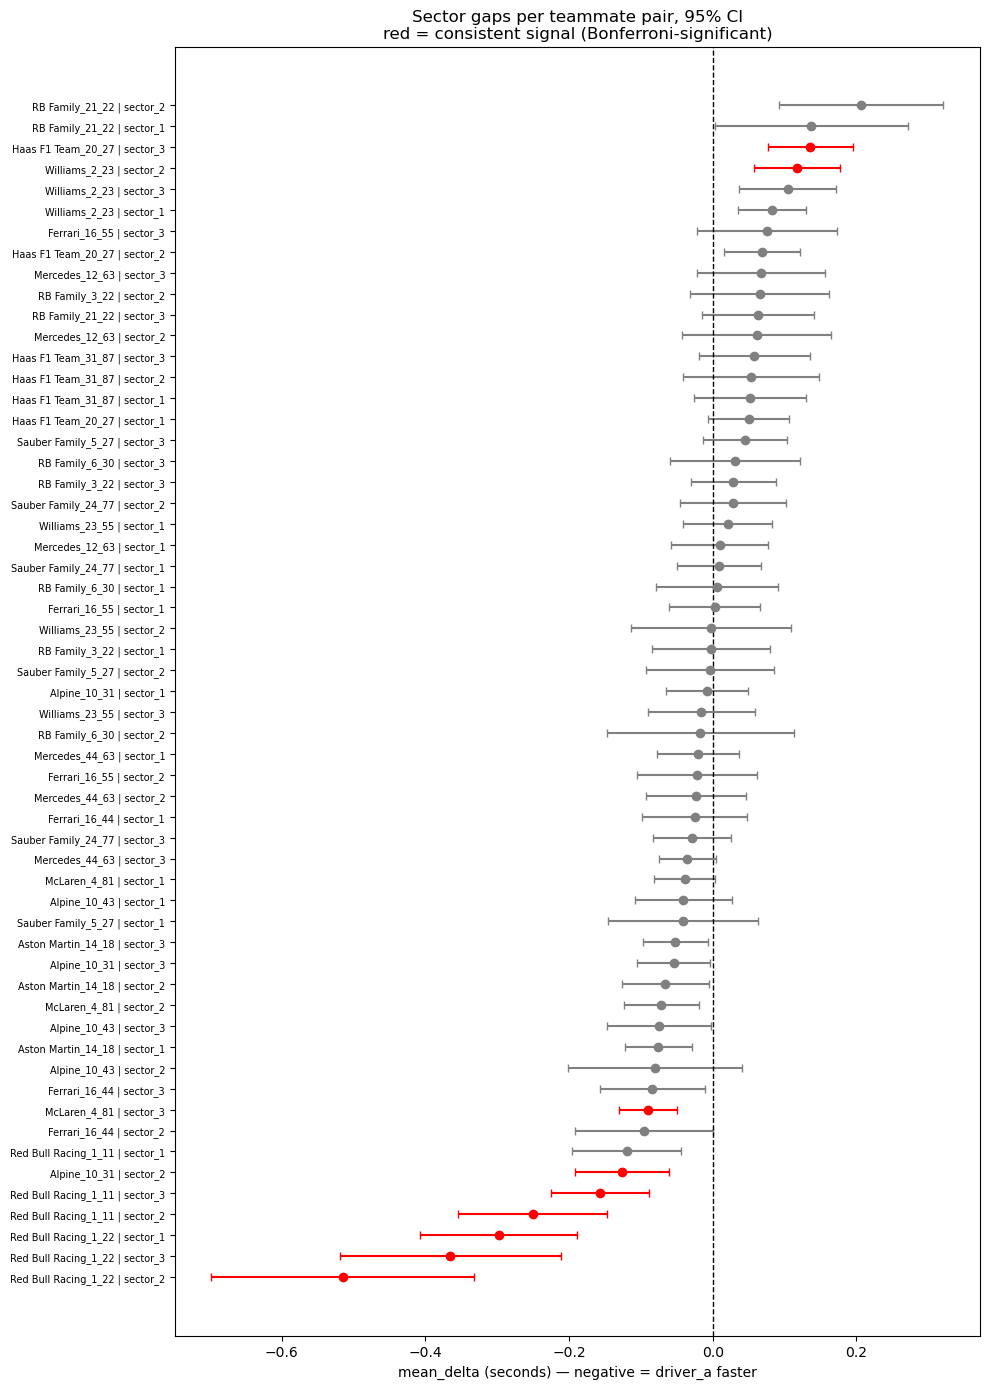

In [37]:
import matplotlib.pyplot as plt
import numpy as np

pair_sector_tests['se'] = pair_sector_tests['std_delta'] / np.sqrt(pair_sector_tests['n_races'])

plot_df = pair_sector_tests.sort_values('mean_delta').reset_index(drop=True)
plot_df['label'] = plot_df['pair_id'] + ' | ' + plot_df['sector']

sig_mask = plot_df['significant']

fig, ax = plt.subplots(figsize=(10, 14))

# gray error bars for non-significant
ax.errorbar(
    plot_df.loc[~sig_mask, 'mean_delta'], 
    plot_df.loc[~sig_mask].index,
    xerr=1.96 * plot_df.loc[~sig_mask, 'se'],
    fmt='o', ecolor='gray', mfc='gray', mec='gray', capsize=3
)

# red error bars for significant
ax.errorbar(
    plot_df.loc[sig_mask, 'mean_delta'], 
    plot_df.loc[sig_mask].index,
    xerr=1.96 * plot_df.loc[sig_mask, 'se'],
    fmt='o', ecolor='red', mfc='red', mec='red', capsize=3
)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df['label'], fontsize=7)
ax.set_xlabel('mean_delta (seconds) — negative = driver_a faster')
ax.set_title('Sector gaps per teammate pair, 95% CI\nred = consistent signal (Bonferroni-significant)')
plt.tight_layout()
plt.show()

RESULT: 9 of 57 pair × sector combinations show a statistically consistent signal.

The 9 significant signals:
  Red Bull Racing:  Verstappen faster than Perez #11 in sector 1 (small), 2, 3
                    Verstappen faster than Perez #22 in sector 1 (small), 2, 3
  McLaren:          Norris faster than Piastri in sector 3
  Alpine:           Ocon faster than Gasly in sector 2
  Haas:             Hulkenberg faster than Magnussen in sector 3
  Williams:         Sainz faster than Albon in sector 3

Notable NON-finding: Alonso vs Stroll (Aston Martin) does not appear despite 
having the largest overall qualifying gap in this project's data (~0.47s in quali). 
Race sector medians are noisier than qualifying single-lap deltas -- the race-to-
race variability in his sector times is too high for the sector-level signal to 
survive Bonferroni correction, even though his overall pace gap is real.

TAKEAWAY:
Sector strength IS a real skill signal, but only for a minority of teammate 
pairings (~16% of pair × sector combinations). For most teammate pairs, sector-
level differences are too noisy to be considered reliable signals. When 
consistent signals do exist, they're concentrated in specific driver pairings 
where the underlying gap is large enough to survive race-to-race noise. Race 
sectors are noisier than qualifying single laps as a measurement of sector-
specific skill.

Getting 9 significant results under strict Bonferroni correction is meaningfully 
more than chance would produce (chance would give ~3 false positives even at raw 
alpha=0.05 across 57 tests, and Bonferroni is much stricter than that).


The plot IS the answer to the question -- it shows the entire distribution of 
pair-sector signals at once, in a way the coefficient tables from earlier attempts 
could not.

- [X] When teammates' strategies diverge, what predicts which one pays off pit timing, track position at the stop, or pure pace? (logistic regression: better-finisher ~ predictors)